# 🇱🇰 Sri Lanka Class AA Road Network — Junction Dataset

**Practical Data Science Module — Road Network Analysis**

This notebook analyses Sri Lanka's **Class AA national road network** using OpenStreetMap data (via `osmnx`) cross-referenced against the official **Road Development Authority (RDA)** gazetted road list.

**Pipeline:**
1. Load official RDA ground-truth data  
2. Fetch and filter OSM road network  
3. Clean & match road references  
4. Validate against official lengths  
5. Detect and classify junctions  
6. Visualise the network and junctions  
7. Export enriched CSV dataset for Kaggle  

**Data Sources:**  
- Road Development Authority (RDA): https://rda.gov.lk  
- OpenStreetMap contributors: https://www.openstreetmap.org  
- OSM data accessed via `osmnx` (Overpass API)

**License:** OpenStreetMap data © OpenStreetMap contributors, ODbL 1.0

---
## 0. Dependencies & Configuration

In [13]:
# Install dependencies if needed (uncomment)
!pip install osmnx geopandas matplotlib pandas shapely folium


   ---------- ----------------------------- 1/4 [jinja2]
   ---------- ----------------------------- 1/4 [jinja2]
   ------------------------------ --------- 3/4 [folium]
   ------------------------------ --------- 3/4 [folium]
   ------------------------------ --------- 3/4 [folium]
   ---------------------------------------- 4/4 [folium]



In [14]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from shapely.geometry import Point
import warnings
import os

warnings.filterwarnings('ignore')

# ── OSMnx settings ──────────────────────────────────────────────────────────
ox.settings.max_query_area_size = 10**12   # Sri Lanka is large
ox.settings.timeout            = 300       # generous timeout
ox.settings.use_cache          = True      # avoid re-downloading

# ── Output directory ────────────────────────────────────────────────────────
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ All imports loaded successfully.")
print(f"   osmnx version : {ox.__version__}")
print(f"   geopandas ver : {gpd.__version__}")

✅ All imports loaded successfully.
   osmnx version : 2.1.0
   geopandas ver : 1.1.3


---
## 1. Official RDA Ground-Truth Dataset

The RDA gazetted list is the **authoritative source** for Sri Lanka's national road network.  
Source: https://rda.gov.lk/index.php?option=com_content&view=article&id=24&Itemid=123&lang=en

We also build the correct OSM `ref` tag mapping:
- `AA001` → `A1` (OSM convention for Sri Lanka trunk/primary roads)
- `AA010` → `A10`
- `AA035` → `A35`

In [15]:
# ── Official RDA data (all 36 Class AA roads) ────────────────────────────────
rda_data = {
    'route_no': [
        'AA000','AA001','AA002','AA003','AA004','AA005','AA006','AA007','AA008',
        'AA009','AA010','AA011','AA012','AA013','AA014','AA015','AA016','AA017',
        'AA018','AA019','AA020','AA021','AA022','AA023','AA024','AA025','AA026',
        'AA027','AA028','AA029','AA030','AA031','AA032','AA033','AA034','AA035'
    ],
    'road_name': [
        'Kollupitiya - Sri Jayewardenepura',
        'Colombo - Kandy',
        'Colombo - Galle - Hambantota - Wellawaya',
        'Peliyagoda - Puttalam',
        'Colombo - Ratnapura - Wellawaya - Batticaloa',
        'Peradeniya - Badulla - Chenkaladi',
        'Ambepussa - Kurunegala - Trincomalee',
        'Avissawella - Hatton - Nuwara Eliya',
        'Panadura - Nambapana - Ratnapura',
        'Kandy - Jaffna',
        'Katugastota - Kurunegala - Puttalam',
        'Maradankadawela - Habarana - Tirikkondiadimadu',
        'Puttalam - Trincomalee',
        'Galkulama - Anuradhapura',
        'Medawachchiya - Mannar - Talaimannar',
        'Batticaloa - Tirikkondiadimadu - Trincomalee',
        'Beragala - Hali-Ela',
        'Galle - Deniyaya - Madampe',
        'Pelmadulla - Embilipitiya - Nonagama',
        'Polgahawela - Kegalle',
        'Anuradhapura - Rambewa',
        'Kegalle - Bulathkohupitiya - Karawanella',
        'Passara - Moneragala',
        'Wellawaya - Ella - Kumbalwela',
        'Matara - Akuressa',
        'Siyambalanduwa - Damana - Ampara',
        'Kandy - Mahiyangana - Padiyatalawa',
        'Ampara - Uhana - MahaOya',
        'Padeniya - Anuradhapura',
        'Vavuniya - Horowopotana',
        'Vavuniya - Parayanalankulam',
        'Karativu - Ampara',
        'Navakkuli - Kerativu - Mannar',
        'Ja-Ela - Ekala - Gampaha - Yakkala',
        'Mankulam - Mullaitivu',
        'Paranthan - Kachchai - Mullaitivu'
    ],
    'official_length_km': [
        7.12, 115.85, 317.78, 126.31, 430.57, 275.64, 198.71, 118.70,
        67.77, 321.00, 124.58, 129.36, 176.99,  16.64, 113.84, 130.86,
        40.39, 143.93,  87.69,  11.67,  14.48,  42.12,  34.11,  30.57,
        20.11,  57.12, 105.23,  57.92,  80.52,  46.02,  35.80,  24.14,
        98.37,  17.02,  49.25,  52.13
    ]
}

df_rda = pd.DataFrame(rda_data)

# ── Build correct OSM ref mapping ────────────────────────────────────────────
# RDA: AA000 → OSM: A0, AA001 → A1, AA010 → A10, AA035 → A35
# Logic: strip leading zeros from the numeric part after "AA"
def rda_to_osm_ref(route_no: str) -> str:
    """Convert RDA route number to OSM 'ref' tag format."""
    # AA035 → numeric part is '035' → strip zeros → '35' → 'A35'
    numeric = route_no.replace('AA', '')  # '035'
    return f"A{int(numeric)}"             # 'A35'

df_rda['osm_ref'] = df_rda['route_no'].apply(rda_to_osm_ref)

print(f"✅ Loaded {len(df_rda)} Class AA roads from RDA dataset")
print(f"   Total official network length: {df_rda['official_length_km'].sum():.2f} km")
print()
print(df_rda[['route_no', 'osm_ref', 'road_name', 'official_length_km']].to_string(index=False))

✅ Loaded 36 Class AA roads from RDA dataset
   Total official network length: 3720.31 km

route_no osm_ref                                      road_name  official_length_km
   AA000      A0              Kollupitiya - Sri Jayewardenepura                7.12
   AA001      A1                                Colombo - Kandy              115.85
   AA002      A2       Colombo - Galle - Hambantota - Wellawaya              317.78
   AA003      A3                          Peliyagoda - Puttalam              126.31
   AA004      A4   Colombo - Ratnapura - Wellawaya - Batticaloa              430.57
   AA005      A5              Peradeniya - Badulla - Chenkaladi              275.64
   AA006      A6           Ambepussa - Kurunegala - Trincomalee              198.71
   AA007      A7            Avissawella - Hatton - Nuwara Eliya              118.70
   AA008      A8               Panadura - Nambapana - Ratnapura               67.77
   AA009      A9                                 Kandy - Jaffna       

---
## 2. Fetch OSM Road Network

We fetch `trunk` and `primary` road types from OpenStreetMap — these are the highway classes that correspond to Class AA roads in Sri Lanka.  
We use `retain_all=True` so no nodes are dropped during graph simplification.

In [16]:
print("⏳ Fetching OSM road network for Sri Lanka...")
print("   (This may take 1–3 minutes; results are cached after first run)")

PLACE = "Sri Lanka"
# trunk  = expressways & major national highways (most AA roads)
# primary = main roads (some AA roads like AA000, AA033 are tagged primary)
FILTER = '["highway"~"trunk|primary"]'

G = ox.graph_from_place(
    PLACE,
    network_type='drive',
    custom_filter=FILTER,
    retain_all=True   # keep all nodes; do not prune endpoints
)

nodes, edges = ox.graph_to_gdfs(G)

print(f"\n✅ Network fetched successfully")
print(f"   Total nodes : {len(nodes):,}")
print(f"   Total edges : {len(edges):,}")
print(f"   CRS         : {edges.crs}")

⏳ Fetching OSM road network for Sri Lanka...
   (This may take 1–3 minutes; results are cached after first run)

✅ Network fetched successfully
   Total nodes : 3,961
   Total edges : 8,153
   CRS         : epsg:4326


---
## 3. Filter Class AA Roads

### OSM `ref` tag parsing

OSM edges can have messy `ref` fields:
- Multiple refs separated by `;` (e.g. `"A1; A6"`)
- Refs with spaces (e.g. `"A 1"`)
- `NaN` for untagged edges

We expand multi-ref edges so each ref is checked individually.

In [17]:
# ── Step 1: Normalise the 'ref' column ───────────────────────────────────────
aa_refs = set(df_rda['osm_ref'])  # {'A0','A1','A2',...,'A35'}

def extract_matching_refs(ref_value, target_refs):
    """
    Given an OSM ref value (may be NaN, a string, or a list),
    return the first matching AA ref, or None.

    osmnx stores 'ref' as:
      - float NaN          → no tag
      - str  'A1'          → single ref
      - str  'A1;A6'       → multiple refs joined by semicolon
      - list ['A1', 'A6']  → osmnx parsed multiple values into a list

    IMPORTANT: pd.isna() raises ValueError when passed a list,
    so we must check isinstance(list) BEFORE calling pd.isna().
    """
    # ① Handle list first — pd.isna() cannot accept a list
    if isinstance(ref_value, list):
        parts = [str(p) for p in ref_value]
    # ② Explicit None
    elif ref_value is None:
        return None
    else:
        # ③ Safe scalar NaN check (float NaN, np.nan, pd.NA)
        try:
            if pd.isna(ref_value):
                return None
        except (TypeError, ValueError):
            pass  # not NaN-like; treat as string
        parts = str(ref_value).split(';')

    for part in parts:
        cleaned = str(part).strip().replace(' ', '')
        if cleaned in target_refs:
            return cleaned
    return None

edges['matched_ref'] = edges['ref'].apply(
    lambda r: extract_matching_refs(r, aa_refs)
)

# ── Step 2: Filter to Class AA edges only ────────────────────────────────────
edges_aa = edges[edges['matched_ref'].notna()].copy()

# Attach RDA metadata (road name, official length) via osm_ref join
edges_aa = edges_aa.merge(
    df_rda[['osm_ref', 'route_no', 'road_name', 'official_length_km']],
    left_on='matched_ref', right_on='osm_ref',
    how='left'
)

print(f"✅ Class AA road edges found : {len(edges_aa):,}")
print(f"   Unique OSM refs matched   : {edges_aa['matched_ref'].nunique()}")
print()

# Show which roads were NOT matched (OSM coverage gap)
matched_refs = set(edges_aa['matched_ref'].unique())
missing_refs = aa_refs - matched_refs
if missing_refs:
    missing_roads = df_rda[df_rda['osm_ref'].isin(missing_refs)][['route_no','osm_ref','road_name']]
    print(f"⚠️  {len(missing_refs)} roads NOT found in OSM (data gap):")
    print(missing_roads.to_string(index=False))
else:
    print("🎉 All 36 Class AA roads found in OSM!")


✅ Class AA road edges found : 2,009
   Unique OSM refs matched   : 28

⚠️  8 roads NOT found in OSM (data gap):
route_no osm_ref                                    road_name
   AA006      A6         Ambepussa - Kurunegala - Trincomalee
   AA014     A14         Medawachchiya - Mannar - Talaimannar
   AA015     A15 Batticaloa - Tirikkondiadimadu - Trincomalee
   AA027     A27                     Ampara - Uhana - MahaOya
   AA029     A29                      Vavuniya - Horowopotana
   AA030     A30                  Vavuniya - Parayanalankulam
   AA034     A34                        Mankulam - Mullaitivu
   AA035     A35            Paranthan - Kachchai - Mullaitivu


---
## 4. Data Validation — OSM Length vs. Official RDA Length

We compute the length of each road as represented in OSM and compare it to the official RDA figures.  
Discrepancies >10% flag potential OSM tagging gaps or road re-alignments.

In [18]:
# ── Compute OSM lengths (project to metric CRS first) ────────────────────────
# Use Sri Lanka national grid (EPSG:5235) for accurate distance measurement
edges_aa_proj = edges_aa.to_crs(epsg=5235)
edges_aa_proj['segment_length_m'] = edges_aa_proj.geometry.length

# Aggregate by route
osm_lengths = (
    edges_aa_proj
    .groupby('matched_ref')['segment_length_m']
    .sum()
    .div(1000)  # m → km
    .reset_index()
    .rename(columns={'matched_ref': 'osm_ref', 'segment_length_m': 'osm_length_km'})
)

# Merge with RDA data
df_validation = df_rda.merge(osm_lengths, on='osm_ref', how='left')
df_validation['osm_length_km'] = df_validation['osm_length_km'].fillna(0)
df_validation['diff_km']       = df_validation['osm_length_km'] - df_validation['official_length_km']
df_validation['diff_pct']      = (df_validation['diff_km'] / df_validation['official_length_km'] * 100).round(1)
df_validation['coverage_flag'] = df_validation['diff_pct'].apply(
    lambda x: '✅ Good' if abs(x) <= 10 else ('⚠️ Over' if x > 10 else '❌ Under')
)

display_cols = ['route_no','road_name','official_length_km','osm_length_km','diff_km','diff_pct','coverage_flag']
print("=" * 90)
print("  OSM vs. Official RDA Length Validation")
print("=" * 90)
print(df_validation[display_cols].to_string(index=False, float_format='{:.2f}'.format))
print("=" * 90)
print(f"  Official total : {df_validation['official_length_km'].sum():.2f} km")
print(f"  OSM total      : {df_validation['osm_length_km'].sum():.2f} km")
good  = (df_validation['coverage_flag'] == '✅ Good').sum()
under = (df_validation['coverage_flag'] == '❌ Under').sum()
over  = (df_validation['coverage_flag'] == '⚠️ Over').sum()
print(f"  Coverage       : {good} good | {under} under-mapped | {over} over-mapped")

  OSM vs. Official RDA Length Validation
route_no                                      road_name  official_length_km  osm_length_km  diff_km  diff_pct coverage_flag
   AA000              Kollupitiya - Sri Jayewardenepura                7.12          13.33     6.21     87.20       ⚠️ Over
   AA001                                Colombo - Kandy              115.85         233.29   117.44    101.40       ⚠️ Over
   AA002       Colombo - Galle - Hambantota - Wellawaya              317.78         604.08   286.30     90.10       ⚠️ Over
   AA003                          Peliyagoda - Puttalam              126.31         253.72   127.41    100.90       ⚠️ Over
   AA004   Colombo - Ratnapura - Wellawaya - Batticaloa              430.57         849.16   418.59     97.20       ⚠️ Over
   AA005              Peradeniya - Badulla - Chenkaladi              275.64         544.78   269.14     97.60       ⚠️ Over
   AA006           Ambepussa - Kurunegala - Trincomalee              198.71           0.00 

---
## 5. Junction Detection

A **junction** (intersection) is a node where roads branch. We use graph degree to classify junction types:

| Node degree | Meaning |
|-------------|----------|
| 1 | Dead end (terminus) |
| 2 | Pass-through / mid-road node |
| ≥ 3 | **Junction** — branching point |

We detect two categories:
- **AA–AA junction**: where two or more *different* AA roads meet
- **AA–any junction**: where an AA road meets any other road (B roads, expressways, etc.)

In [19]:
# ── Build node-level AA road membership ──────────────────────────────────────
# After the earlier .merge(), edges_aa has a flat RangeIndex, not the osmnx
# MultiIndex (u, v, key). We recover u/v from the index of the *original*
# edges GeoDataFrame before the merge corrupted it.

# Re-derive u/v directly from the filtered (pre-merge) edges
# edges_aa still has the original MultiIndex if merge used left_on/right_on
# but to be safe we reconstruct from the graph itself.
edges_aa_reset = (
    edges                                          # original full edge GDF
    .reset_index()                                 # u, v, key become columns
    .loc[lambda df: df['ref'].apply(
        lambda r: extract_matching_refs(r, aa_refs)) .notna()]
    .copy()
)
edges_aa_reset['matched_ref'] = edges_aa_reset['ref'].apply(
    lambda r: extract_matching_refs(r, aa_refs)
)

# Map: node_id → set of AA refs touching it
node_aa_refs: dict = {}
for _, row in edges_aa_reset.iterrows():
    ref = row['matched_ref']
    for node_id in [row['u'], row['v']]:
        node_aa_refs.setdefault(node_id, set()).add(ref)

# ── Identify junction types ───────────────────────────────────────────────────
junction_records = []

for node_id, aa_ref_set in node_aa_refs.items():
    if node_id not in nodes.index:
        continue

    node_row     = nodes.loc[node_id]
    street_count = node_row.get('street_count', 0)
    # street_count may be a Series if the node appears multiple times
    if hasattr(street_count, 'iloc'):
        street_count = int(street_count.iloc[0])
    else:
        street_count = int(street_count) if street_count else 0

    n_aa_refs = len(aa_ref_set)

    is_aa_aa_junction   = n_aa_refs >= 2
    is_aa_any_junction  = street_count >= 3

    if is_aa_aa_junction or is_aa_any_junction:
        geom = node_row.geometry
        # geometry may also be a Series for duplicated nodes
        if hasattr(geom, 'iloc'):
            geom = geom.iloc[0]
        junction_records.append({
            'node_id'            : node_id,
            'latitude'           : geom.y,
            'longitude'          : geom.x,
            'street_count'       : street_count,
            'n_aa_roads'         : n_aa_refs,
            'aa_roads'           : ';'.join(sorted(aa_ref_set)),
            'is_aa_aa_junction'  : is_aa_aa_junction,
            'is_aa_any_junction' : is_aa_any_junction,
            'junction_type'      : 'AA-AA' if is_aa_aa_junction else 'AA-Other',
            'geometry'           : geom
        })

df_junctions  = pd.DataFrame(junction_records)
gdf_junctions = gpd.GeoDataFrame(df_junctions, geometry='geometry', crs=edges.crs)

n_aa_aa  = int(df_junctions['is_aa_aa_junction'].sum())
n_aa_any = int(df_junctions['is_aa_any_junction'].sum())
n_total  = len(df_junctions)

print(f"✅ Junction detection complete")
print(f"   Total junctions found    : {n_total:,}")
print(f"   AA-AA junctions          : {n_aa_aa:,}  (where 2+ AA roads meet)")
print(f"   AA-Any junctions (total) : {n_aa_any:,}  (where AA meets any road)")
print()
print("Sample AA-AA junctions:")
print(
    df_junctions[df_junctions['is_aa_aa_junction']]
    [['latitude','longitude','aa_roads','street_count']]
    .head(10)
    .to_string(index=False)
)


✅ Junction detection complete
   Total junctions found    : 1,473
   AA-AA junctions          : 44  (where 2+ AA roads meet)
   AA-Any junctions (total) : 1,473  (where AA meets any road)

Sample AA-AA junctions:
 latitude  longitude aa_roads  street_count
 7.264124  80.592941    A1;A5             3
 6.732073  81.101954    A2;A4             3
 6.731658  81.099805   A23;A4             4
 6.873477  81.031248  A16;A23             3
 6.032158  80.239635   A17;A2             3
 6.960735  80.769262    A5;A7             3
 6.090296  80.476194  A17;A24             3
 7.293033  80.637749    A1;A9             3
 6.685328  80.396078    A4;A8             3
 8.127337  80.562747   A11;A9             4


---
## 6. Visualisation

### 6a. Full network map — all Class AA roads with junction overlay

In [20]:
import folium
import matplotlib.colors as mcolors
import pandas as pd

# 1. Extract and clean the 'lanes' data so it is uniformly stored
def clean_lanes(lane_val):
    if isinstance(lane_val, list):
        return lane_val[0] # Take the first value if OSM returns a list
    if pd.isna(lane_val):
        return "Unknown"
    return str(lane_val)

edges_aa['lanes_cleaned'] = edges_aa['lanes'].apply(clean_lanes)

# 2. Initialize the map centered on Sri Lanka
# 'CartoDB positron' provides a clean, empty base map so your roads stand out
m = folium.Map(location=[7.8731, 80.7718], zoom_start=7, tiles='CartoDB positron')

# 3. Create Interactive Layers (FeatureGroups)
layer_roads = folium.FeatureGroup(name='Class AA Roads')
layer_aa_junc = folium.FeatureGroup(name='AA-AA Junctions', show=True)
layer_other_junc = folium.FeatureGroup(name='AA-Other Junctions', show=False) # Hidden by default to avoid clutter

# 4. Add the Roads with Hover Tooltips
# Ensure coordinates are in standard Lat/Lon (EPSG:4326)
edges_aa_4326 = edges_aa.to_crs(epsg=4326)

for idx, row in edges_aa_4326.iterrows():
    geom = row['geometry']
    ref = row['matched_ref']
    lanes = row['lanes_cleaned']
    
    # Convert matplotlib RGBA colors to Hex colors for Folium
    rgba_color = ref_to_color.get(ref, (0.2, 0.5, 0.8, 1.0))
    hex_color = mcolors.to_hex(rgba_color)
    
    # Create the tooltip text showing Road Number and Lanes
    tooltip_html = f"<b>Road:</b> {ref}<br><b>Name:</b> {row.get('road_name', 'N/A')}<br><b>Lanes:</b> {lanes}"
    
    # Handle both single line segments and multi-line segments
    if geom.geom_type == 'LineString':
        coords = [(lat, lon) for lon, lat in geom.coords]
        folium.PolyLine(locations=coords, color=hex_color, weight=3, tooltip=tooltip_html).add_to(layer_roads)
    elif geom.geom_type == 'MultiLineString':
        for line in geom.geoms:
            coords = [(lat, lon) for lon, lat in line.coords]
            folium.PolyLine(locations=coords, color=hex_color, weight=3, tooltip=tooltip_html).add_to(layer_roads)

# 5. Add the Junctions to the Filterable Layers
for idx, row in gdf_junctions.iterrows():
    is_aa_aa = row['is_aa_aa_junction']
    
    # Route to the correct toggleable layer
    target_layer = layer_aa_junc if is_aa_aa else layer_other_junc
    color = '#ff4757' if is_aa_aa else '#ffa502'
    radius = 5 if is_aa_aa else 3
    
    tooltip_html = f"<b>Type:</b> {'AA-AA' if is_aa_aa else 'AA-Other'}<br><b>Connecting:</b> {row['aa_roads']}"
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.8,
        tooltip=tooltip_html
    ).add_to(target_layer)

# 6. Add all layers to the map and inject the Layer Control (the filter)
layer_roads.add_to(m)
layer_aa_junc.add_to(m)
layer_other_junc.add_to(m)

folium.LayerControl(position='topright', collapsed=False).add_to(m)

# 7. Save and Display
html_path = f"{OUTPUT_DIR}/interactive_map_aa_network.html"
m.save(html_path)
print(f"✅ Interactive Map saved to {html_path}")

# Calling 'm' at the end of the cell will display the interactive map right inside the Jupyter Notebook
m

✅ Interactive Map saved to outputs/interactive_map_aa_network.html


### 6b. Validation chart — OSM vs. Official road lengths

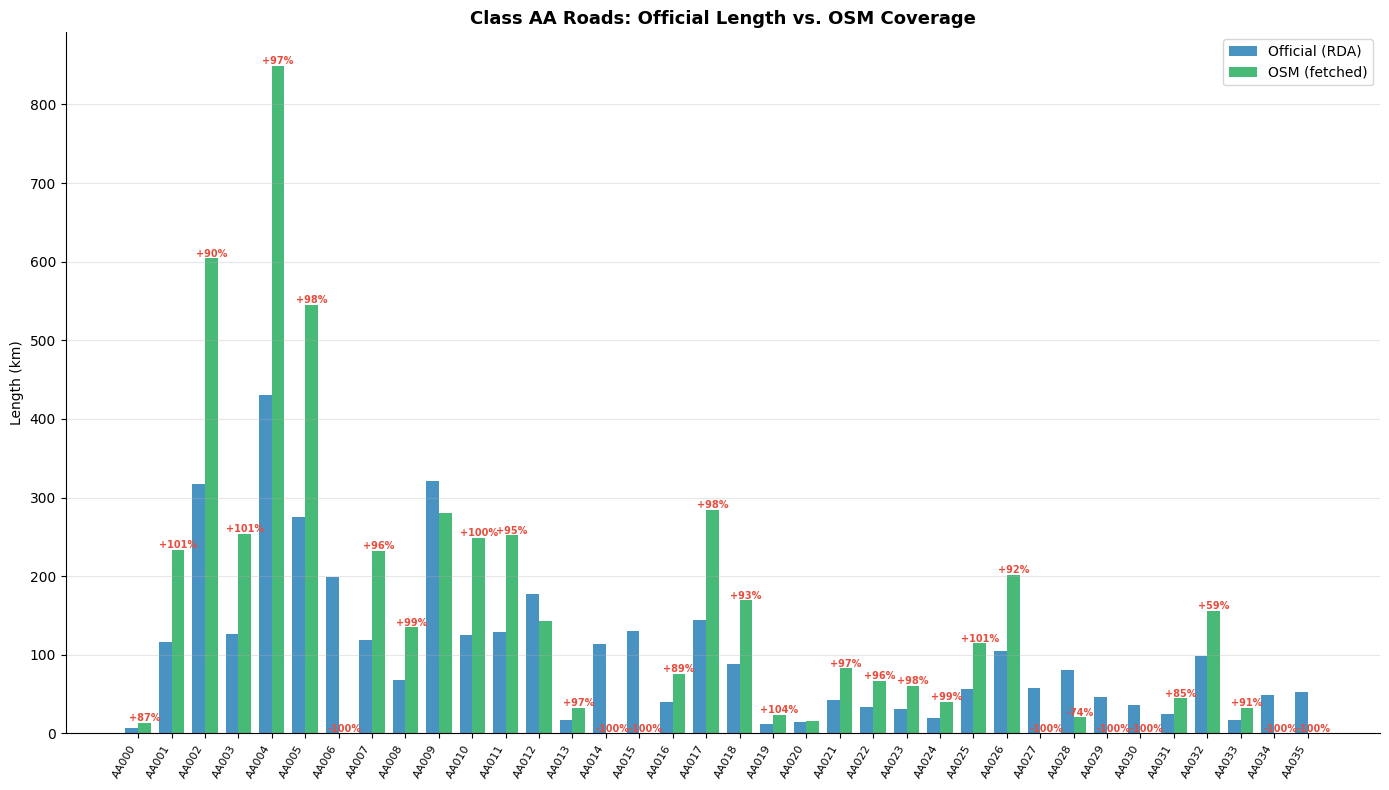

✅ Chart saved to outputs/chart_length_validation.png


In [21]:
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(df_validation))
width = 0.38

bars_official = ax.bar(x - width/2, df_validation['official_length_km'],
                       width, label='Official (RDA)', color='#2980b9', alpha=0.85)
bars_osm      = ax.bar(x + width/2, df_validation['osm_length_km'],
                       width, label='OSM (fetched)', color='#27ae60', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df_validation['route_no'], rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Length (km)')
ax.set_title('Class AA Roads: Official Length vs. OSM Coverage', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Annotate large discrepancies
for i, row in df_validation.iterrows():
    if abs(row['diff_pct']) > 20:
        ax.annotate(f"{row['diff_pct']:+.0f}%",
                    xy=(i + width/2, row['osm_length_km'] + 2),
                    ha='center', fontsize=7, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_length_validation.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved to {OUTPUT_DIR}/chart_length_validation.png")

### 6c. Junction degree distribution

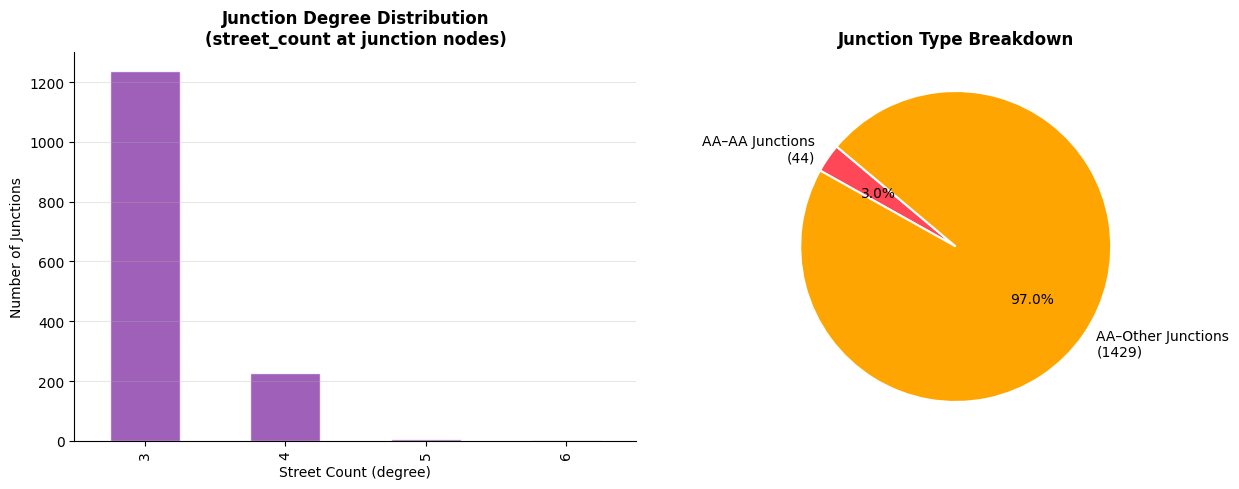

✅ Chart saved to outputs/chart_junction_stats.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: street_count histogram
ax = axes[0]
df_junctions['street_count'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='#8e44ad', edgecolor='white', alpha=0.85
)
ax.set_title('Junction Degree Distribution\n(street_count at junction nodes)', fontweight='bold')
ax.set_xlabel('Street Count (degree)')
ax.set_ylabel('Number of Junctions')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Right: AA–AA vs AA–Other pie
ax2 = axes[1]
sizes  = [n_aa_aa, n_total - n_aa_aa]
labels = [f'AA–AA Junctions\n({n_aa_aa})', f'AA–Other Junctions\n({n_total - n_aa_aa})']
colors = ['#ff4757', '#ffa502']
wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax2.set_title('Junction Type Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_junction_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved to {OUTPUT_DIR}/chart_junction_stats.png")

---
## 7. Export Datasets for Kaggle

We export three CSVs:
1. **`junctions.csv`** — all detected junctions with full metadata
2. **`roads_summary.csv`** — per-road summary with OSM vs. official length comparison
3. **`edges_aa.csv`** — raw edge-level data (individual road segments)

In [23]:
# ── 7a. Junctions CSV ─────────────────────────────────────────────────────────
junctions_export = df_junctions[[
    'node_id', 'latitude', 'longitude',
    'street_count', 'n_aa_roads', 'aa_roads',
    'junction_type', 'is_aa_aa_junction', 'is_aa_any_junction'
]].copy()
junctions_export = junctions_export.round({'latitude': 6, 'longitude': 6})
junctions_path = f"{OUTPUT_DIR}/sri_lanka_aa_junctions.csv"
junctions_export.to_csv(junctions_path, index=False)
print(f"✅ Junctions CSV  -> {junctions_path}  ({len(junctions_export):,} rows)")

# ── 7b. Roads summary CSV ─────────────────────────────────────────────────────
roads_summary = df_validation[[
    'route_no', 'osm_ref', 'road_name',
    'official_length_km', 'osm_length_km', 'diff_km', 'diff_pct', 'coverage_flag'
]].copy()

def count_junctions_for_ref(ref, aa_only=False):
    mask = df_junctions['aa_roads'].apply(lambda r: ref in r.split(';'))
    if aa_only:
        mask = mask & df_junctions['is_aa_aa_junction']
    return int(mask.sum())

roads_summary['n_junctions_total'] = roads_summary['osm_ref'].apply(
    lambda ref: count_junctions_for_ref(ref, aa_only=False)
)
roads_summary['n_aa_aa_junctions'] = roads_summary['osm_ref'].apply(
    lambda ref: count_junctions_for_ref(ref, aa_only=True)
)
roads_path = f"{OUTPUT_DIR}/sri_lanka_aa_roads_summary.csv"
roads_summary.to_csv(roads_path, index=False)
print(f"✅ Roads summary  -> {roads_path}  ({len(roads_summary):,} rows)")

# ── 7c. Edges (raw segments) CSV ──────────────────────────────────────────────
# edges_aa_proj was created from edges_aa which lost u/v into columns after merge.
# Re-use edges_aa_reset (which has u/v as proper columns) joined with lengths.
edges_aa_reset_proj = edges_aa_reset.copy()
edges_aa_reset_proj = edges_aa_reset_proj.set_geometry('geometry').to_crs(epsg=5235)
edges_aa_reset_proj['segment_length_m'] = edges_aa_reset_proj.geometry.length

# Merge road names back in
edges_aa_reset_proj = edges_aa_reset_proj.merge(
    df_rda[['osm_ref', 'route_no', 'road_name']],
    left_on='matched_ref', right_on='osm_ref',
    how='left'
)

# Select available columns safely
wanted = ['u', 'v', 'matched_ref', 'route_no', 'road_name',
          'highway', 'oneway', 'maxspeed', 'lanes', 'name', 'segment_length_m']
available = [c for c in wanted if c in edges_aa_reset_proj.columns]
edges_export = edges_aa_reset_proj[available].copy()

edges_path = f"{OUTPUT_DIR}/sri_lanka_aa_road_segments.csv"
edges_export.to_csv(edges_path, index=False)
print(f"✅ Road segments  -> {edges_path}  ({len(edges_export):,} rows)")


✅ Junctions CSV  -> outputs/sri_lanka_aa_junctions.csv  (1,473 rows)
✅ Roads summary  -> outputs/sri_lanka_aa_roads_summary.csv  (36 rows)
✅ Road segments  -> outputs/sri_lanka_aa_road_segments.csv  (2,009 rows)


---
## 8. Summary Report

In [24]:
print("=" * 60)
print("  SRI LANKA CLASS AA ROAD NETWORK — ANALYSIS SUMMARY")
print("=" * 60)
print()
print(f"  Data source   : OpenStreetMap (via osmnx)")
print(f"  Ground truth  : RDA Sri Lanka gazetted network")
print(f"  Road class    : Class AA (national highways)")
print()
print(f"  Roads in RDA dataset   : {len(df_rda)}")
print(f"  Roads found in OSM     : {edges_aa['matched_ref'].nunique()}")
print(f"  Roads missing from OSM : {len(df_rda) - edges_aa['matched_ref'].nunique()}")
print()
print(f"  Official total length  : {df_rda['official_length_km'].sum():.2f} km")
print(f"  OSM total length       : {df_validation['osm_length_km'].sum():.2f} km")
print()
print(f"  Total junctions        : {n_total}")
print(f"    ├─ AA–AA junctions   : {n_aa_aa}")
print(f"    └─ AA–Other          : {n_total - n_aa_aa}")
print()
print(f"  Exported files:")
print(f"    ├─ {OUTPUT_DIR}/sri_lanka_aa_junctions.csv")
print(f"    ├─ {OUTPUT_DIR}/sri_lanka_aa_roads_summary.csv")
print(f"    └─ {OUTPUT_DIR}/sri_lanka_aa_road_segments.csv")
print()
print("  ⚠️  Notes for Kaggle dataset card:")
print("    - OSM data is community-maintained; coverage varies by region")
print("    - Length discrepancies may reflect OSM tagging gaps")
print("    - Junction detection uses graph degree (street_count ≥ 3)")
print("    - Coordinate system: WGS84 (EPSG:4326)")
print("    - Data fetched via Overpass API; timestamp varies")
print("=" * 60)

  SRI LANKA CLASS AA ROAD NETWORK — ANALYSIS SUMMARY

  Data source   : OpenStreetMap (via osmnx)
  Ground truth  : RDA Sri Lanka gazetted network
  Road class    : Class AA (national highways)

  Roads in RDA dataset   : 36
  Roads found in OSM     : 28
  Roads missing from OSM : 8

  Official total length  : 3720.31 km
  OSM total length       : 5212.28 km

  Total junctions        : 1473
    ├─ AA–AA junctions   : 44
    └─ AA–Other          : 1429

  Exported files:
    ├─ outputs/sri_lanka_aa_junctions.csv
    ├─ outputs/sri_lanka_aa_roads_summary.csv
    └─ outputs/sri_lanka_aa_road_segments.csv

  ⚠️  Notes for Kaggle dataset card:
    - OSM data is community-maintained; coverage varies by region
    - Length discrepancies may reflect OSM tagging gaps
    - Junction detection uses graph degree (street_count ≥ 3)
    - Coordinate system: WGS84 (EPSG:4326)
    - Data fetched via Overpass API; timestamp varies
